In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("DailyDelhiClimateMerged.csv")
df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1576 entries, 0 to 1575
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1576 non-null   object 
 1   meantemp      1576 non-null   float64
 2   humidity      1576 non-null   float64
 3   wind_speed    1576 non-null   float64
 4   meanpressure  1576 non-null   float64
dtypes: float64(4), object(1)
memory usage: 61.7+ KB


In [4]:
df.isnull().sum()

date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df["date"] = pd.to_datetime(df["date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1576 entries, 0 to 1575
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          1576 non-null   datetime64[ns]
 1   meantemp      1576 non-null   float64       
 2   humidity      1576 non-null   float64       
 3   wind_speed    1576 non-null   float64       
 4   meanpressure  1576 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 61.7 KB


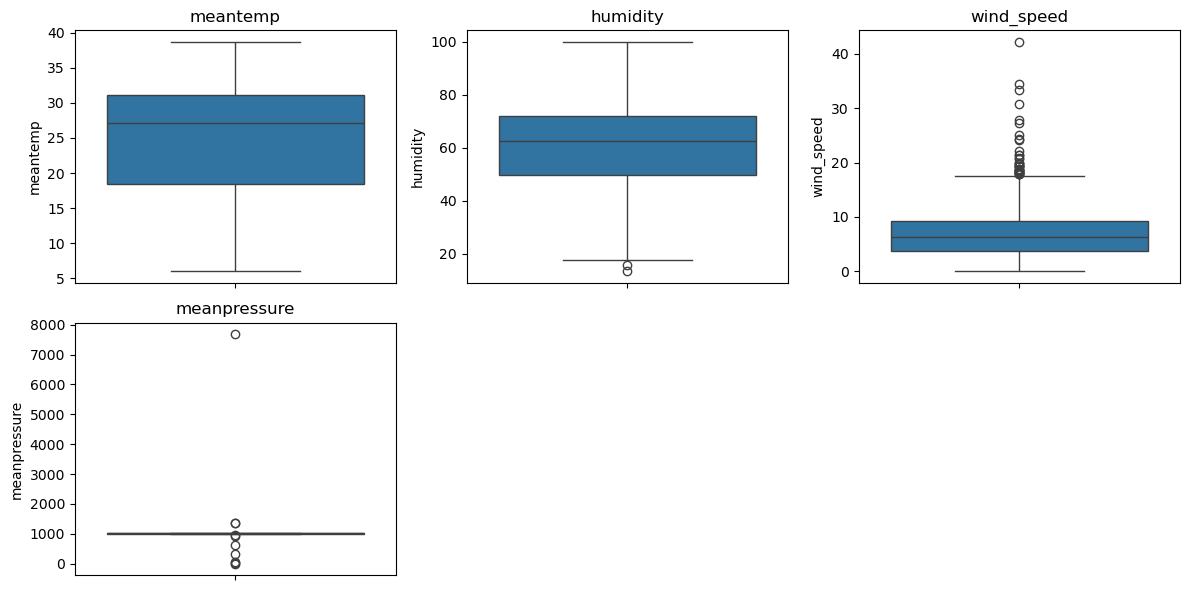

In [7]:
num_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(12,6))
for i, col in enumerate(num_cols):
    plt.subplot(2,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [8]:
invalid = df[(df["meanpressure"] < 900) | (df["meanpressure"] > 1100)]
print("Number of invalid values :", len(invalid))
invalid

Number of invalid values : 8


,date,meantemp,humidity,wind_speed,meanpressure
1182,2016-03-28,25.933333,52.800000,6.546667,7679.333333
1309,2016-08-02,30.687500,72.125000,6.375000,310.437500
1321,2016-08-14,28.933333,83.700000,6.370000,633.900000
1323,2016-08-16,31.333333,66.416667,14.666667,-3.041667
1362,2016-09-24,31.240000,66.480000,5.496154,1352.615385
1416,2016-11-17,21.730769,51.730769,11.550000,1350.296296
1427,2016-11-28,22.454545,37.318182,9.185714,12.045455
1462,2017-01-01,15.913043,85.869565,2.743478,59.000000


In [13]:
df.loc[
    (df["meanpressure"] < 900) |
    (df["meanpressure"] > 1100),
    "meanpressure"
] = np.nan
df["meanpressure"] = df["meanpressure"].interpolate(method="linear")

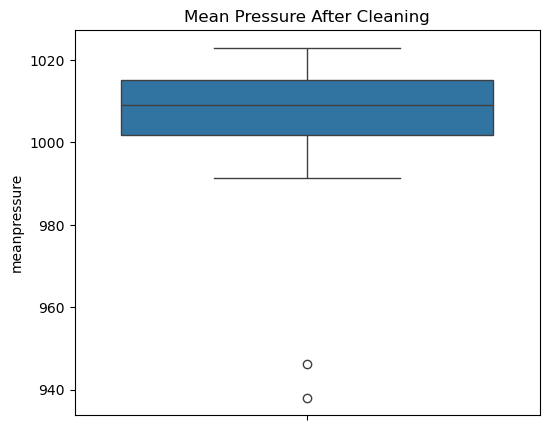

,date,meantemp,humidity,wind_speed,meanpressure


In [14]:
plt.figure(figsize=(6,5))
sns.boxplot(y=df["meanpressure"])
plt.title("Mean Pressure After Cleaning")
plt.show()

df[(df["meanpressure"] < 900) | (df["meanpressure"] > 1100)]

In [15]:
df.describe()

,date,meantemp,humidity,wind_speed,meanpressure
count,1576,1576.000000,1576.000000,1576.000000,1576.000000
mean,2015-02-27 10:15:50.253807104,25.221918,60.445229,6.899262,1008.479264
min,2013-01-01 00:00:00,6.000000,13.428571,0.000000,938.066667
25%,2014-01-29 18:00:00,18.500000,49.750000,3.700000,1001.875000
50%,2015-02-27 12:00:00,27.166667,62.440476,6.363571,1009.118056
75%,2016-03-27 06:00:00,31.142857,72.125000,9.262500,1015.175000
max,2017-04-24 00:00:00,38.714286,100.000000,42.220000,1023.000000
std,NaN,7.345014,16.979994,4.510725,7.767949


In [16]:
df.isnull().sum()

date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1576 entries, 0 to 1575
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          1576 non-null   datetime64[ns]
 1   meantemp      1576 non-null   float64       
 2   humidity      1576 non-null   float64       
 3   wind_speed    1576 non-null   float64       
 4   meanpressure  1576 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 61.7 KB


In [17]:
df.to_csv("DailyDelhiClimateCleaned.csv", index=False)
print("Dataset saved successfully.")

Dataset saved successfully.
